# Detecting Spam with Multiple Machine Learning Methods
## Knights of Spamalot

In [1]:
import numpy as np
from sklearn.preprocessing import (LabelEncoder, MinMaxScaler)
from sklearn.compose import ColumnTransformer

import pandas as pd
from sklearn.pipeline import Pipeline

import nltk
import string
from sklearn.feature_extraction.text import CountVectorizer
from sklearn import svm
from sklearn.model_selection import GridSearchCV
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from sklearn.model_selection import KFold, cross_val_score, cross_validate
from sklearn.model_selection import ShuffleSplit
import matplotlib.pyplot as plt

In [2]:
df1 = pd.read_csv("SMSSpamCollection", sep="\t", header=None)
df1.columns = ["Label", "EmailText"]

df1

,Label,EmailText
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [3]:
df2 = pd.read_csv("Dataset_5971.csv")
df2 = df2.drop(columns=["URL", "EMAIL", "PHONE"])
df2.columns = ["Label", "EmailText"]
df2["Label"] = df2["Label"].replace(["Smishing", "Spam", "smishing"], "spam")
df2

,Label,EmailText
0,ham,Your opinion about me? 1. Over 2. Jada 3. Kusr...
1,ham,What's up? Do you want me to come online? If y...
2,ham,So u workin overtime nigpun?
3,ham,"Also sir, i sent you an email about how to log..."
4,spam,Please Stay At Home. To encourage the notion o...
...,...,...
5966,ham,:( but your not here....
5967,ham,Becoz its &lt;#&gt; jan whn al the post ofic...
5968,ham,Its a valentine game. . . send dis msg to all ...
5969,ham,We r outside already.


In [4]:
#df3 spambase

In [5]:
df = pd.concat([df1, df2], ignore_index=True)

In [6]:
encoder = LabelEncoder()
df['Label'] = encoder.fit_transform(df['Label'])

In [7]:
df

,Label,EmailText
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
11538,0,:( but your not here....
11539,0,Becoz its &lt;#&gt; jan whn al the post ofic...
11540,0,Its a valentine game. . . send dis msg to all ...
11541,0,We r outside already.


In [8]:
# removing all the duplicate values and keeping only the first
df = df.drop_duplicates(keep='first')

In [9]:
df.shape

(6317, 2)

In [10]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [11]:
def get_importantFeatures(sent):
    sent = sent.lower()
    
    returnList = []
    sent = nltk.word_tokenize(sent)
    for i in sent:
        if i.isalnum():
            returnList.append(i)
    return returnList

def removing_stopWords(sent):
    returnList = []
    for i in sent:
        if i not in nltk.corpus.stopwords.words('english') and i not in string.punctuation:
            returnList.append(i)
    return returnList

def potter_stem(sent):
    returnList = []
    for i in sent:
        returnList.append(ps.stem(i))
    return " ".join(returnList)

In [12]:
df['imp_feature'] = df['EmailText'].apply(get_importantFeatures)
df['imp_feature'] = df['imp_feature'].apply(removing_stopWords)
df['imp_feature'] = df['imp_feature'].apply(potter_stem)

/var/folders/4v/24znp9xs0391f5wl4v3y48dr0000gn/T/ipykernel_68213/3465550335.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['imp_feature'] = df['EmailText'].apply(get_importantFeatures)
/var/folders/4v/24znp9xs0391f5wl4v3y48dr0000gn/T/ipykernel_68213/3465550335.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['imp_feature'] = df['imp_feature'].apply(removing_stopWords)
/var/folders/4v/24znp9xs0391f5wl4v3y48dr0000gn/T/ipykernel_68213/3465550335.py:3: SettingWithCopyWarning: 
A value is trying to

In [13]:
# Numeric Pipeline
num_pipe = Pipeline(
    steps = [
        ("encoder",MinMaxScaler())
    ]
)

# Extract numeric column names from predictors
numeric_cols=df.select_dtypes(
    include=["number"]
).columns
numeric_cols

num_pipe

Pipeline(steps=[('encoder', MinMaxScaler())])

In [14]:
# Text pipeline
"""text_pipe = Pipeline(
    steps = ["vectorizer", TfidfVectorizer()
    ]
)
text_pipe"""
text_pipe = Pipeline(
    steps = []
)

# Extract text column names from predictors
text_cols=df.select_dtypes(
    include=["string"]
).columns
text_cols


text_pipe

Pipeline(steps=[])

In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", num_pipe, numeric_cols),
        ("text", text_pipe, text_cols)
    ],
    remainder='drop'  # or 'passthrough' if you want to keep unlisted columns
)
preprocessor

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('encoder', MinMaxScaler())]),
                                 Index(['Label'], dtype='object')),
                                ('text', Pipeline(steps=[]),
                                 Index([], dtype='object'))])

In [16]:
from sklearn.model_selection import train_test_split
X = df['imp_feature']
y = df['Label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [17]:
X_train

4921                              g say never answer text
3033                jokin lar depend phone father get lor
5122                  enufcredeit ileav uni 6 bu yor hous
651       that cool sometim slow gentl sonetim rough hard
6072    today vodafon number end 4865 select receiv aw...
                              ...                        
4016         receiv week tripl echo rington shortli enjoy
5655    noida commerci wave silver psf gold psf logix ...
5830    winner valu network custom select receivea pri...
6664                                  sunday holiday work
879     u secret admir look 2 make contact r reveal th...
Name: imp_feature, Length: 4737, dtype: object

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [19]:
tfidf = TfidfVectorizer()
feature = tfidf.fit_transform(X_train)

tuned_parameters = {'kernel':['linear','rbf'],'gamma':[1e-3,1e-4], 'C':[1,10,100,1000]}

model = GridSearchCV(svm.SVC(),tuned_parameters)
model.fit(feature, y_train)

GridSearchCV(estimator=SVC(),
             param_grid={'C': [1, 10, 100, 1000], 'gamma': [0.001, 0.0001],
                         'kernel': ['linear', 'rbf']})

In [20]:
y_predict = tfidf.transform(X_test)
print("Accuracy:",model.score(y_predict,y_test))

Accuracy: 0.9854430379746836


In [22]:
search_space = {'kernel':['linear','rbf'],'gamma':[1e-3,1e-4], 'C':[1,10,100,1000]}

In [23]:
opt = BayesSearchCV(
     svm.SVC(),
     {
         'C': Real(1e-6, 1e+6),
         'gamma': Real(1e-6, 1e+1),
         'kernel': Categorical(['linear', 'poly', 'rbf']),
     },
     n_iter=32,
     random_state=0
 )

In [24]:
_ = opt.fit(feature, y_train)

/Users/kaibankston/opt/miniconda3/lib/python3.9/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [1000000.0, 1e-06, 'linear'] before, using random point [729444.5369459819, 1.9445890971171753, 'rbf']
  warnings.warn(


In [25]:
print("Best score:", opt.best_score_)
print("Best parameters:", opt.best_params_)
predictions = opt.predict(tfidf.transform(X_test))

Best score: 0.9744574249573381
Best parameters: OrderedDict([('C', 1818.1224344861832), ('gamma', 0.3258746568638726), ('kernel', 'rbf')])


In [26]:
X = df['imp_feature']
y = df['Label']

tfidf = TfidfVectorizer()
feature = tfidf.fit_transform(X)

# Configure Repeated Random Test-Train splits
ss = ShuffleSplit(n_splits=10, test_size=0.25, random_state=42)

In [27]:
scoring_metrics = ['accuracy', 'precision', 'f1', 'roc_auc']

In [28]:
# Perform Repeated Random Test-Train splits and print scores
scores = cross_validate(model, feature, y, scoring = scoring_metrics, cv=ss)

In [29]:
#print("Repeated Random Test-Train Split scores:", scores)
print("Average accuracy:",scores['test_accuracy'].mean())
print("Average precision:",scores['test_precision'].mean())
print("Average F1 score:",scores['test_f1'].mean())
print("Average ROC AUC:",scores['test_roc_auc'].mean())

Average accuracy: 0.9759493670886075
Average precision: 0.984627483258093
Average F1 score: 0.9340299117812079
Average ROC AUC: 0.991599311330936


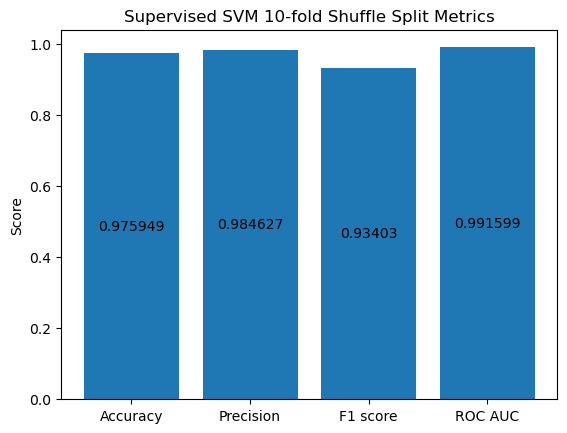

In [30]:
fig, ax = plt.subplots()

metrics = ['Accuracy', 'Precision', 'F1 score', 'ROC AUC']
counts = [scores['test_accuracy'].mean(), scores['test_precision'].mean(), scores['test_f1'].mean(), scores['test_roc_auc'].mean()]

barplot = ax.bar(metrics, counts)

ax.set_ylabel('Score')
ax.set_title('Supervised SVM 10-fold Shuffle Split Metrics')
ax.bar_label(barplot, label_type='center')
plt.savefig('my_plot.png', dpi=300, bbox_inches='tight')

In [31]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y, y_predict)

InvalidParameterError: The 'y_pred' parameter of confusion_matrix must be an array-like. Got <1580x6296 sparse matrix of type '<class 'numpy.float64'>'
	with 12198 stored elements in Compressed Sparse Row format> instead.

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = cross_val_predict(_, feature, y, cv=5)

cm = confusion_matrix(y, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()
plt.show()

/Users/kaibankston/opt/miniconda3/lib/python3.9/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [1000000.0, 1e-06, 'linear'] before, using random point [150237.0305901442, 0.7762691897211239, 'linear']
  warnings.warn(
